# 모의고사 7회 | 고객 이탈 예측

## 문제

### 데이터셋
- `customer_data.json`: 고객 기본 정보
- `call_history.csv`: 고객 통화 이력

### 컬럼 정보

**customer_data.json**
- CustomerID: 고객 고유 ID
- SubscriptionType: 구독 종류 ('Basic', 'Standard', 'Premium')
- MonthlyCharges_USD: 월 요금 (USD)
- TotalUsage_GB: 총 사용량 (GB)
- ContractDuration_Months: 계약 기간 (개월)
- ServiceRegion: 서비스 지역 ('RegionA', 'RegionB', 'RegionC')
- IsNewCustomer: 신규 고객 여부 (boolean: true, false)
- Churn: 이탈 여부 (0: 이탈하지 않음, 1: 이탈) - 예측 대상 변수 (Target Variable)

**call_history.csv**
- CustomerID: 고객 고유 ID
- CallCenterInteractions: 콜센터 상호작용 횟수
- ComplaintCount: 불만 제기 횟수
- TechSupportTickets: 기술 지원 티켓 수
- PaymentIssues: 결제 문제 발생 여부 (0: 없음, 1: 있음)

---


## 7-1 | 라이브러리 임포트 및 데이터 로딩

### 【❓문제】
데이터 분석에 필요한 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터 파일을 읽어 데이터프레임으로 할당하는 코드를 작성하세요.

- customer_data.json 파일을 읽어 데이터프레임의 변수 df_customer에 할당하세요.
- call_history.csv 파일을 읽어 데이터프레임의 변수 df_call에 할당하세요.

---


In [1]:
# 라이브러리 임포트
import pandas as pd

In [2]:
# 데이터 불러오기
df_customer = pd.read_json('C:/juehyeon/aice_test/기출문제/7.고객이탈예측/customer_data.json')

In [3]:
# 데이터 확인
df_customer.info() # 범주형 변수: SubscriptionType, ServiceRegion , 결측치 : totalusage_gb 30개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               600 non-null    object 
 1   SubscriptionType         600 non-null    object 
 2   MonthlyCharges_USD       600 non-null    float64
 3   TotalUsage_GB            570 non-null    float64
 4   ContractDuration_Months  600 non-null    int64  
 5   ServiceRegion            600 non-null    object 
 6   IsNewCustomer            600 non-null    bool   
 7   Churn                    600 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 33.5+ KB


In [4]:
##### 데이터 불러오기 2
df_call = pd.read_csv('C:/juehyeon/aice_test/기출문제/7.고객이탈예측/call_history.csv')

In [5]:
# 데이터 확인
df_call.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              600 non-null    object
 1   CallCenterInteractions  600 non-null    int64 
 2   ComplaintCount          600 non-null    int64 
 3   TechSupportTickets      600 non-null    int64 
 4   PaymentIssues           600 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 23.6+ KB


## 7-2 | 데이터 병합

### 【❓문제】
두 개의 데이터프레임(df_customer, df_call)을 CustomerID를 기준으로 병합하는 코드를 작성하세요.

- pandas의 merge 함수를 사용하여 df_customer와 df_call을 CustomerID를 키(key)로 병합하고 df 변수에 저장하세요.

- 병합 방식은 left로 지정하여 모든 고객 데이터를 유지하되 병합하세요.

---


In [6]:
# 데이터 병합
df = pd.merge(df_customer, df_call, on = 'CustomerID', how = 'left')

In [7]:
# 병합 데이터 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               600 non-null    object 
 1   SubscriptionType         600 non-null    object 
 2   MonthlyCharges_USD       600 non-null    float64
 3   TotalUsage_GB            570 non-null    float64
 4   ContractDuration_Months  600 non-null    int64  
 5   ServiceRegion            600 non-null    object 
 6   IsNewCustomer            600 non-null    bool   
 7   Churn                    600 non-null    int64  
 8   CallCenterInteractions   600 non-null    int64  
 9   ComplaintCount           600 non-null    int64  
 10  TechSupportTickets       600 non-null    int64  
 11  PaymentIssues            600 non-null    int64  
dtypes: bool(1), float64(2), int64(6), object(3)
memory usage: 52.3+ KB


## 7-3 | 불필요 컬럼 삭제

### 【❓문제】
모델링에 불필요한 CustomerID 컬럼을 삭제하는 코드를 작성하세요.

- df에서 CustomerID 컬럼을 삭제하세요.

---


In [8]:
# 컬럼 삭제
df = df.drop(columns = 'CustomerID', axis = 1)

In [9]:
# 컬럼 삭제 확인
df.columns

Index(['SubscriptionType', 'MonthlyCharges_USD', 'TotalUsage_GB',
       'ContractDuration_Months', 'ServiceRegion', 'IsNewCustomer', 'Churn',
       'CallCenterInteractions', 'ComplaintCount', 'TechSupportTickets',
       'PaymentIssues'],
      dtype='object')

## 7-4 | 결측치 처리(최빈값 대체)

### 【❓문제】
TotalUsage_GB 컬럼에 결측치가 있다고 가정하고, 해당 컬럼의 결측치를 최빈값(mode)으로 대체하는 코드를 작성하세요.

- df의 TotalUsage_GB 컬럼이 있는 결측치를 최빈값으로 대체하세요.

---


In [10]:
# 최빈값 
mode_tu = df['TotalUsage_GB'].mode()[0]

In [11]:
# 결측치 확인
df['TotalUsage_GB'].isna().sum()

np.int64(30)

In [12]:
# 결측치 대체
df['TotalUsage_GB'] = df['TotalUsage_GB'].fillna(mode_tu)

In [13]:
# 결측치 대체 확인
df['TotalUsage_GB'].isna().sum()

np.int64(0)

## 7-5 | 범주형 변수 토큰 시각화

### 【❓문제】
SubscriptionType과 ServiceRegion 컬럼의 분포를 시각화하여 데이터의 균형 여부를 확인하세요.

- matplotlib.pyplot과 seaborn 라이브러리를 사용하여 SubscriptionType과 ServiceRegion의 분포를 각각 막대 그래프로 시각화하세요.

---


In [14]:
# 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns

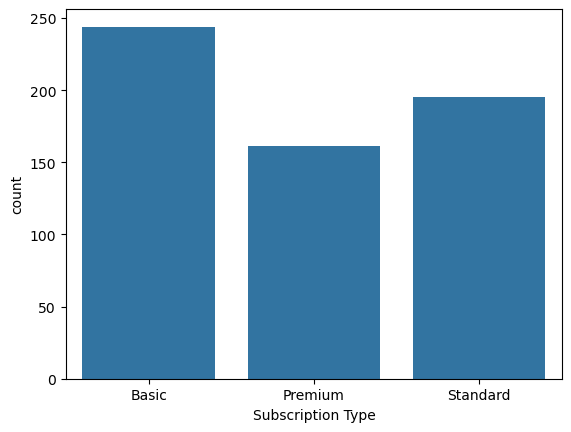

In [15]:
## subscriptionType
sns.countplot(data=df, x='SubscriptionType')
plt.xlabel('Subscription Type')
plt.show()

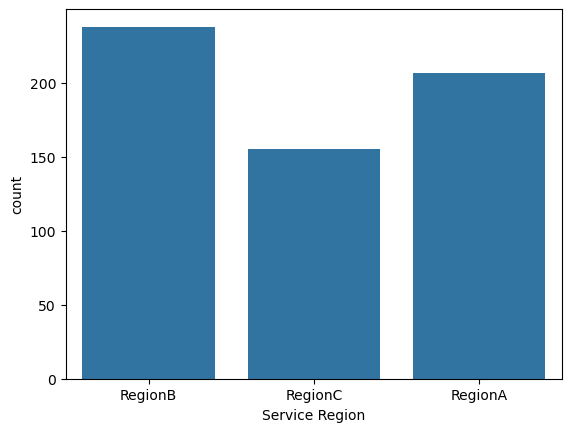

In [16]:
## Service Region
sns.countplot(data = df, x= 'ServiceRegion')
plt.xlabel('Service Region')
plt.show()

## 7-6 | 이진 범주형 변수 조차 변환

### 【❓문제】
IsNewCustomer 컬럼을 True는 1로, False는 0으로 변환하는 코드를 작성하세요.

- astype(int) 함수를 사용하여 IsNewCustomer 컬럼의 값을 변환하고 df에 저장하세요.

---


In [17]:
df['IsNewCustomer'].dtype

dtype('bool')

In [18]:
# 범주형 변수 변환
df['IsNewCustomer'] = df['IsNewCustomer'].astype(int)

In [19]:
# 변환  확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SubscriptionType         600 non-null    object 
 1   MonthlyCharges_USD       600 non-null    float64
 2   TotalUsage_GB            600 non-null    float64
 3   ContractDuration_Months  600 non-null    int64  
 4   ServiceRegion            600 non-null    object 
 5   IsNewCustomer            600 non-null    int64  
 6   Churn                    600 non-null    int64  
 7   CallCenterInteractions   600 non-null    int64  
 8   ComplaintCount           600 non-null    int64  
 9   TechSupportTickets       600 non-null    int64  
 10  PaymentIssues            600 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 51.7+ KB


In [20]:
df['IsNewCustomer'].unique()

array([0, 1])

## 7-7 | 범주형 변수 원-핫 인코딩

### 【❓문제】
SubscriptionType과 ServiceRegion 컬럼을 원-핫 인코딩하세요.

- pandas의 get_dummies 함수를 활용하여 SubscriptionType과 ServiceRegion 컬럼에 대해 원-핫 인코딩을 수행하세요.

- 변경된 결과를 df_encoded 변수에 저장하세요.

---


In [21]:
# 원=핫 인코딩
incod_cols = ['SubscriptionType', 'ServiceRegion']
df = pd.get_dummies(data = df, columns = incod_cols)

In [22]:
# 인코딩 확인
df.columns

Index(['MonthlyCharges_USD', 'TotalUsage_GB', 'ContractDuration_Months',
       'IsNewCustomer', 'Churn', 'CallCenterInteractions', 'ComplaintCount',
       'TechSupportTickets', 'PaymentIssues', 'SubscriptionType_Basic',
       'SubscriptionType_Premium', 'SubscriptionType_Standard',
       'ServiceRegion_RegionA', 'ServiceRegion_RegionB',
       'ServiceRegion_RegionC'],
      dtype='object')

In [23]:
# 변수 재할당
df_encoded = df.copy()

## 7-8 | 데이터 분리 및 스케일링

### 【❓문제】
특성 외로분리(Churn)를 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.

- Churn 컬럼을 y 변수에, 나머지 컬럼들을 X 변수에 할당하세요.

- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)로 분할하세요. random_state는 42로 설정하세요.

- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터의 Feature(X_train)을 스케일링하고 X_train_scaled에 할당하세요.

- StandardScaler의 transform 함수를 사용하여 검증 데이터의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

---


In [24]:
X = df_encoded.drop(columns = 'Churn')
y = df_encoded['Churn']

In [25]:
# 라이브러리 임포트
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [26]:
# 훈련, 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [27]:
# 데이터 분리 확인
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(480, 14) (120, 14) (480,) (120,)


In [28]:
# 데이터 스케일링 객체 생성
scaler = StandardScaler()

In [29]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## 7-9 | 머신러닝 모델 학습(Logistic Regression)

### 【❓문제】
scikit-learn의 LogisticRegression 모델을 생성하고 학습하세요.

- 모델의 random_state는 42로 설정하세요.

- 모델을 logreg_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

---


In [30]:
# 라이브러리 임포트
from sklearn.linear_model import LogisticRegression

In [31]:
# 모델 객체 생성
logreg_model = LogisticRegression(random_state = 42)

In [32]:
# 데이터 학습
logreg_model.fit(X_train_scaled, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7-10 | 머신러닝 모델 학습(Decision Tree)

### 【❓문제】
scikit-learn의 DecisionTreeClassifier 모델을 생성하고 학습하세요.

- 모델의 max_depth는 5, random_state는 42로 설정하세요.

- 모델을 dt_model 변수에 저장하고, 훈련 데이터(X_train, y_train)으로 학습을 진행하세요.

---


In [33]:
# 라이브러리 임포트
from sklearn.tree import DecisionTreeClassifier

In [34]:
# 모델 객체 생성
dt_model = DecisionTreeClassifier(max_depth = 5, random_state =42)

In [35]:
# 모델 학습
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 7-11 | 딥러닝 모델 개발 및 학습

### 【❓문제】
tensorflow.keras를 사용하여 고객 이탈 여부(Churn)를 예측하는 딥러닝 모델을 만들고 학습하세요.

- 은닉 레이어(Hidden Layer)를 2개로 구성하세요.

- 첫 번째 레이어는 32개, 두 번째는 16개의 뉴런을 가지도록 하세요.

- 모든 은닉 레이어에 relu 활성화 함수를 사용하고, 출력 레이어는 이진 분류이므로 sigmoid 활성화 함수를 사용하세요.

- 옵티마이저는 Adam을, 손실 함수는 이진 분류에 적합한 binary_crossentropy를 사용하세요.
- epochs는 30, batch_size는 32로 설정하고, 학습 진행 상황을 history 변수에 저장하세요.

---


In [36]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

In [37]:
# 모델 생성
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(1, activation = 'sigmoid') 
])

In [38]:
# 모델 컴파일
dl_model.compile(
    optimizer = 'adam', 
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)   

In [39]:
# 모델 학습
history = dl_model.fit(X_train_scaled, y_train,
                       epochs = 30, 
                       batch_size = 32, 
                       validation_data = (X_valid_scaled, y_valid)
                      )

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7063 - loss: 0.6085 - val_accuracy: 0.7000 - val_loss: 0.6192
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7146 - loss: 0.5758 - val_accuracy: 0.6917 - val_loss: 0.6104
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7083 - loss: 0.5586 - val_accuracy: 0.6917 - val_loss: 0.6100
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7125 - loss: 0.5464 - val_accuracy: 0.6917 - val_loss: 0.6076
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7146 - loss: 0.5372 - val_accuracy: 0.6917 - val_loss: 0.6064
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7188 - loss: 0.5298 - val_accuracy: 0.7000 - val_loss: 0.6052
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7229 - loss: 0.5231 - val_accuracy: 0.7083 - val_loss: 0.6031
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7208 - loss: 0.5177 - val_accuracy: 0.7083 - va

## 7-12 | 딥러닝 모델 학습 성능 시각화

### 【❓문제】
matplotlib을 활용하여 딥러닝 모델의 학습 정확도와 검증 정확도를 그래프로 표시하여 과적합을 추가하여 성능 변화를 시각화하세요.

- history 변수에 저장된 학습 정확도(accuracy)와 검증 정확도(val_accuracy)를 그래프로 그리세요.

- 각각의 라벨명은 'Training Accuracy'와 'Validation Accuracy'로 표시하세요.

- x축에 'Epochs', y축에 'Accuracy'라는 레이블을 지정하세요.

---


In [40]:
# history 확인
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

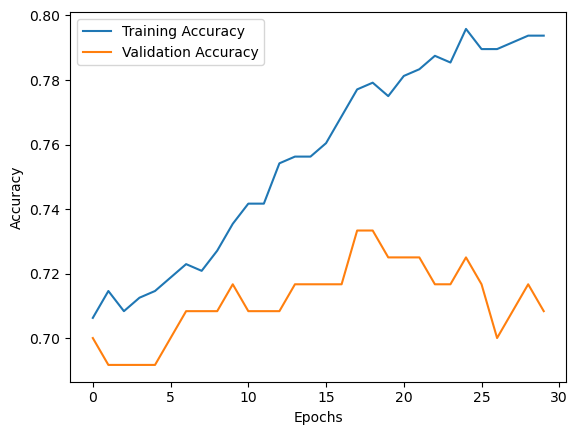

In [41]:
# 그래프 그리기
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 7-13 | 최종 모델 성능 평가 및 결론 도출

### 【❓문제】
세 가지 모델(logreg_model, dt_model, model)의 성능을 검증 데이터(X를 활용하여 정확도(Accuracy)와 F1-score로 평가하고, 가장 우수한 성능을 보인 모델을 선택하세요.

- 각 모델을 사용하여 검증 데이터에서 대한 예측값을 생성하세요.

- scikit-learn의 accuracy_score와 f1_score 함수를 사용하여 각 모델의 성능을 평가하고 출력하세요.
- 세 모델 중 정확도와 F1-Score가 가장 높은 모델의 이름을 best_model_name 변수에 저장하세요.

---


In [42]:
# 라이브러리 임포트
from sklearn.metrics import accuracy_score, f1_score

In [43]:
# 예측
logreg_pred = logreg_model.predict(X_valid_scaled)
dt_pred = dt_model.predict(X_valid)
dl_pred = dl_model.predict(X_valid_scaled)
dl_pred = (dl_pred >= 0.5).astype(int).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [44]:
# 평가 (accuracy_score)
logreg_accuracy = accuracy_score(y_valid, logreg_pred)
dt_accuracy = accuracy_score(y_valid, dt_pred)
dl_accuracy = accuracy_score(y_valid, dl_pred)

In [45]:
# 평가 (f1_score)
logreg_f1_score = f1_score(y_valid, logreg_pred)
dt_f1_score = f1_score(y_valid, dt_pred)
dl_f1_score = f1_score(y_valid, dl_pred)

In [46]:
print(f'Logistic Regressor : {logreg_accuracy}, Decision Tree Classifier : {dt_accuracy}, Deep Learning : {dl_accuracy}')

Logistic Regressor : 0.75, Decision Tree Classifier : 0.6583333333333333, Deep Learning : 0.7083333333333334


In [47]:
f1 = {'Logistic Regressor' : logreg_f1_score, 'Decision Tree Classifier' : dt_f1_score, 'Deep Learning' : dl_f1_score}

In [57]:
print(f'F1_score: \n{f1}')

F1_score: 
{'Logistic Regressor': 0.4, 'Decision Tree Classifier': 0.32786885245901637, 'Deep Learning': 0.33962264150943394}


In [49]:
best_model_name = max(f1, key =  f1.get)
print(best_model_name)

Logistic Regressor


## 7-14 | 비지도 학습 모델을 활용한 고객 세그먼트 분석

### 【❓문제】
비지도 학습을 허용하여 고객 데이터를 여러 그룹(세그먼트)으로 나누고, 각 그룹의 특징을 분석하세요.

- scikit-learn의 KMeans 모델을 사용하여 고객 데이터를 3개의 클러스터로 군집화하세요.

- n_clusters는 3, random_state는 42로 설정하세요.

- 군집화 결과를 df 데이터프레임에 Cluster라는 새로운 컬럼을 추가하세요.

- 4개 Cluster별 MonthlyCharges_USD와 TotalUsage_GB의 평균값을 출력하여 각 클러스터의 특성을 파악하세요.


In [50]:
from sklearn.cluster import KMeans

In [51]:
# 데이터 분리
X_cluster = df_encoded.drop(columns = 'Churn')

In [52]:
# 데이터 스케일링
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [53]:
# 모델 생성
kmeans = KMeans(n_clusters = 3, random_state = 42)

In [54]:
# 변수할당
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [55]:
df.groupby('Cluster')[['MonthlyCharges_USD' , 'TotalUsage_GB']].mean()

,MonthlyCharges_USD,TotalUsage_GB
Cluster,,
0,84.677049,245.557377
1,84.443795,234.866667
2,83.883416,260.155280


In [56]:
# Cluster 0: 월 요금은 약 84.7달러, 사용량은 약 245.6GB로 중간 수준
# Cluster 1: 월 요금은 약 84.4달러, 사용량은 약 234.9GB로 사용량이 가장 낮음
# Cluster 2: 월 요금은 약 83.9달러, 사용량은 약 260.2GB로 사용량이 가장 높음

# 세 군집의 월 요금 차이는 크지 않고, 주로 사용량에서 차이가 나타남